<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/Lab2_nn%26dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv("diabetes.csv")

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
x = df.drop("Outcome", axis=1)
y = df['Outcome']

In [10]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [12]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(x.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [14]:
history = model.fit(x_train, y_train, epochs=50, batch_size=16,
                    validation_data=(x_test, y_test), verbose=1)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4836 - loss: 0.7323 - val_accuracy: 0.6364 - val_loss: 0.6642
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6492 - loss: 0.6466 - val_accuracy: 0.6558 - val_loss: 0.6219
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6703 - loss: 0.6095 - val_accuracy: 0.6623 - val_loss: 0.5936
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6642 - loss: 0.5823 - val_accuracy: 0.6818 - val_loss: 0.5703
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6767 - loss: 0.5522 - val_accuracy: 0.7013 - val_loss: 0.5525
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7143 - loss: 0.5172 - val_accuracy: 0.7078 - val_loss: 0.5418
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7424 - loss: 0.4830 - val_accuracy: 0.7013 - val_loss: 0.5335
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7432 - loss: 0.4942 - val_accuracy: 0.7208 - val_loss

In [15]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test  Accuracy: ", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7398 - loss: 0.5464
Test  Accuracy:  0.7467532753944397


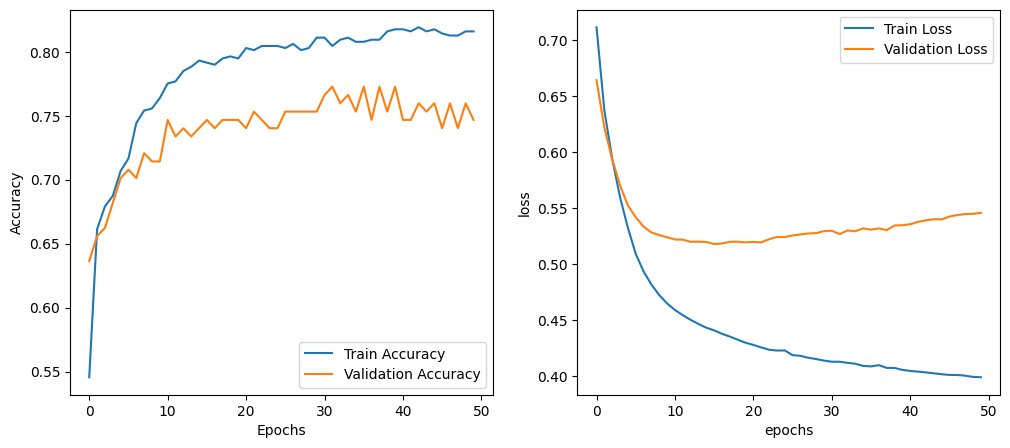

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()